## Processamento de Linguagem Natural - assignment 1

-----
Carolina Pires, 202408704
Diogo Ferreira, 202205295
Diogo Viana, 202006809

## 05. Results Analysis

In this notebook, we analyze the results of the baseline experiments to assess the impact of different text representations on classification performance.

We compare response-only vs response + prompt input, as well as versions with and without punctuation, based on the performance metrics obtained in the previous experiments.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
results_df = pd.read_csv("../results/model_results.csv")

results_df.head()

,dataset,model,accuracy,precision,recall,f1_macro
0,resp_no_punct,Logistic Regression,0.791626,0.790617,0.791303,0.790883
1,comb_no_punct,Logistic Regression,0.791626,0.790668,0.790375,0.790512
2,comb_no_punct,SVM,0.791133,0.790111,0.790189,0.790149
3,resp_no_punct,SVM,0.790394,0.789381,0.789361,0.789371
4,comb_with_punct,Logistic Regression,0.789409,0.788385,0.788405,0.788395


### Model Comparison

In [3]:
results_df.sort_values(by="f1_macro", ascending=False)

,dataset,model,accuracy,precision,recall,f1_macro
0,resp_no_punct,Logistic Regression,0.791626,0.790617,0.791303,0.790883
1,comb_no_punct,Logistic Regression,0.791626,0.790668,0.790375,0.790512
2,comb_no_punct,SVM,0.791133,0.790111,0.790189,0.790149
3,resp_no_punct,SVM,0.790394,0.789381,0.789361,0.789371
4,comb_with_punct,Logistic Regression,0.789409,0.788385,0.788405,0.788395
5,resp_with_punct,Logistic Regression,0.788916,0.787898,0.788563,0.788157
6,comb_with_punct,SVM,0.787438,0.786391,0.786563,0.786473
7,resp_with_punct,SVM,0.784483,0.783433,0.783971,0.783656
8,resp_no_punct,Naive Bayes,0.776601,0.775539,0.775363,0.775447
9,resp_no_punct,Random Forest,0.770690,0.772004,0.773068,0.770603


After Model Comparison:
- Logistic Regression and Linear SVM consistently achieve the highest performance across all dataset variants.
- This result is expected, as linear models are particularly well-suited for high-dimensional and sparse representations such as TF-IDF.

In [4]:
best_per_dataset = results_df.loc[
    results_df.groupby("dataset")["f1_macro"].idxmax()
]

best_per_dataset

,dataset,model,accuracy,precision,recall,f1_macro
1,comb_no_punct,Logistic Regression,0.791626,0.790668,0.790375,0.790512
4,comb_with_punct,Logistic Regression,0.789409,0.788385,0.788405,0.788395
0,resp_no_punct,Logistic Regression,0.791626,0.790617,0.791303,0.790883
5,resp_with_punct,Logistic Regression,0.788916,0.787898,0.788563,0.788157


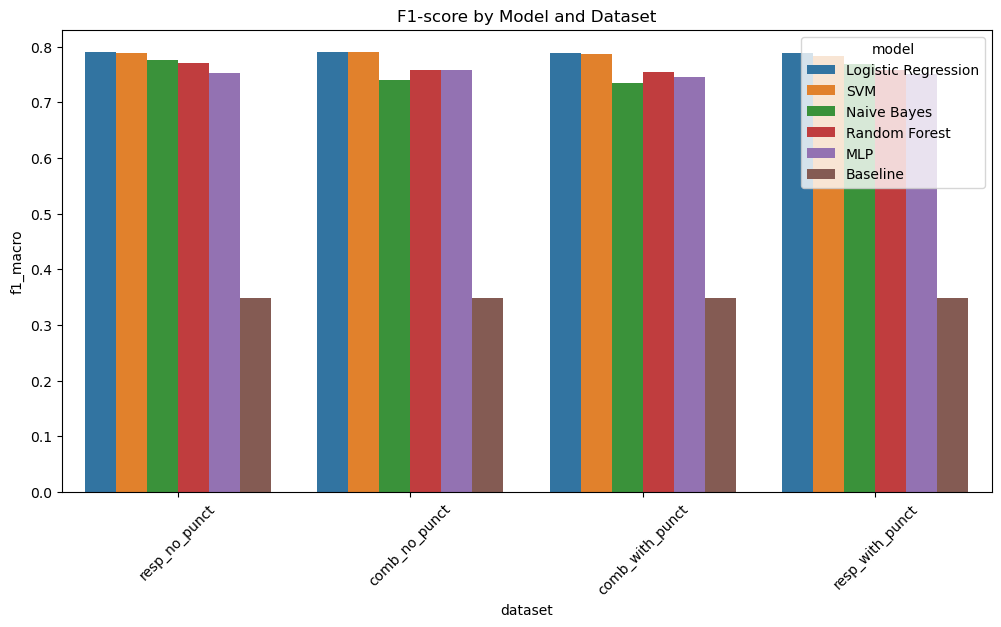

In [5]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=results_df,
    x="dataset",
    y="f1_macro",
    hue="model"
)

plt.title("F1-score by Model and Dataset")
plt.xticks(rotation=45)
plt.show()

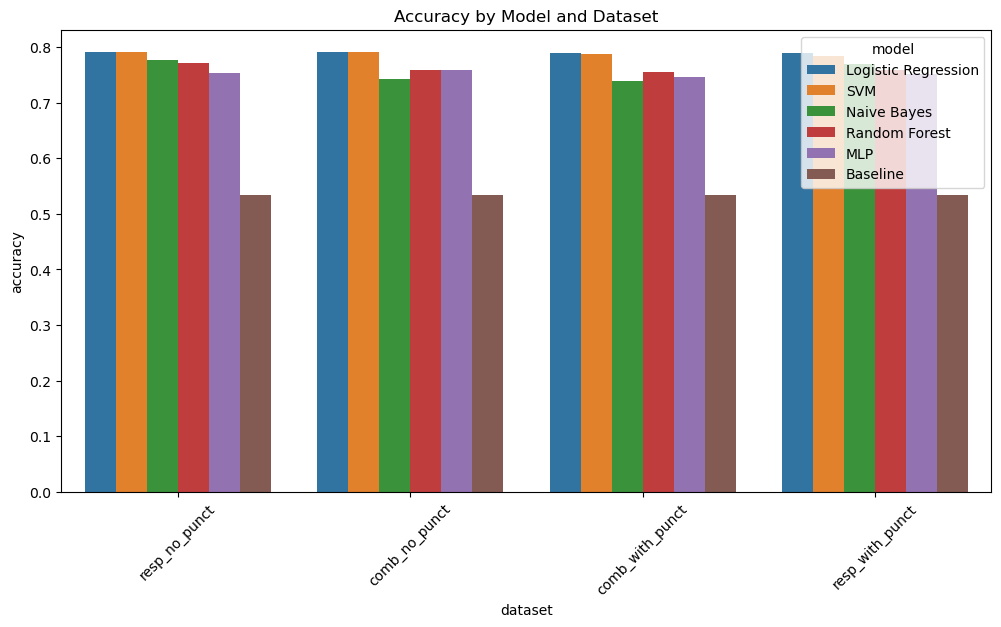

In [6]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=results_df,
    x="dataset",
    y="accuracy",
    hue="model"
)

plt.title("Accuracy by Model and Dataset")
plt.xticks(rotation=45)
plt.show()

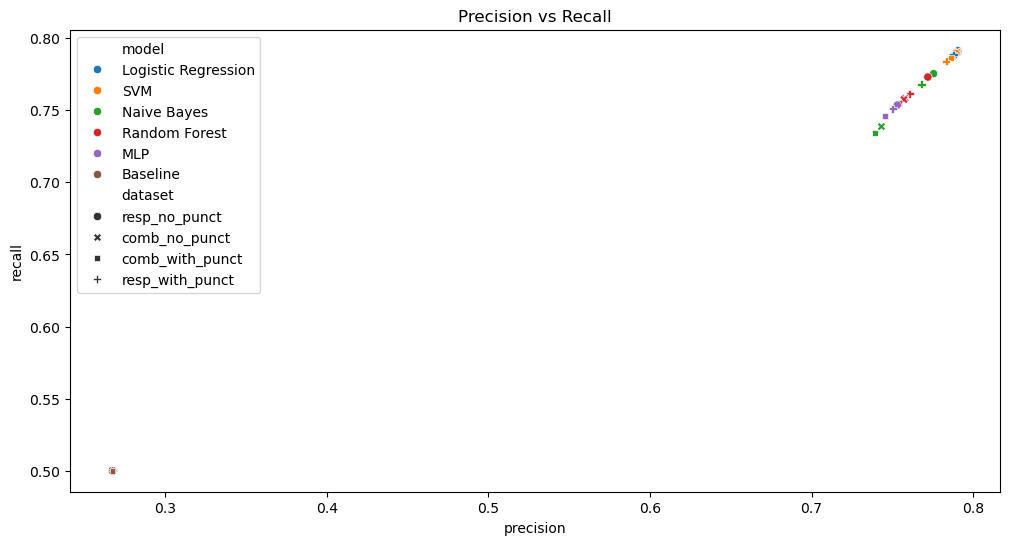

In [7]:
plt.figure(figsize=(12,6))

sns.scatterplot(
    data=results_df,
    x="precision",
    y="recall",
    hue="model",
    style="dataset"
)

plt.title("Precision vs Recall")
plt.show()

In [8]:
model_avg = results_df.groupby("model").mean(numeric_only=True)

model_avg.sort_values(by="f1_macro", ascending=False)

,accuracy,precision,recall,f1_macro
model,,,,
Logistic Regression,0.790394,0.789392,0.789662,0.789487
SVM,0.788362,0.787329,0.787521,0.787412
Random Forest,0.760653,0.761020,0.761757,0.760198
Naive Bayes,0.756897,0.756604,0.754145,0.754641
MLP,0.752771,0.751711,0.752350,0.751926
Baseline,0.534729,0.267365,0.500000,0.348419


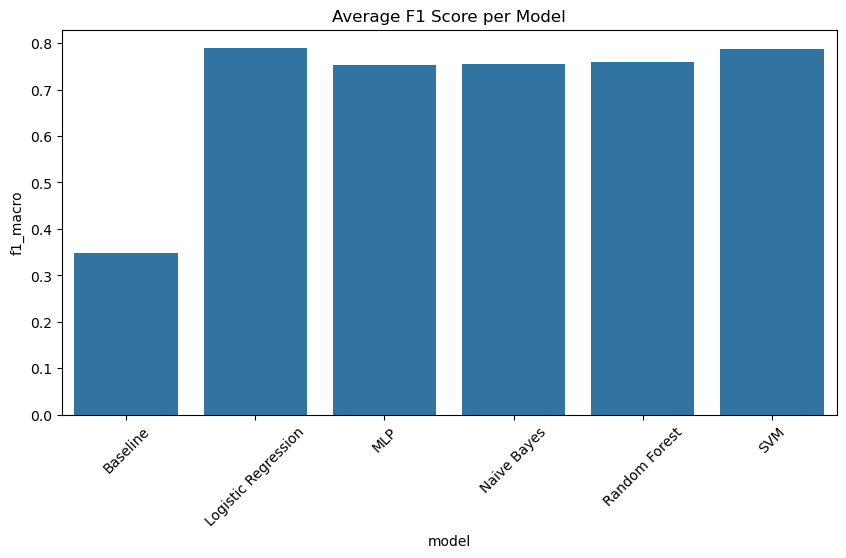

In [9]:
model_avg.reset_index(inplace=True)

plt.figure(figsize=(10,5))

sns.barplot(
    data=model_avg,
    x="model",
    y="f1_macro"
)

plt.title("Average F1 Score per Model")
plt.xticks(rotation=45)
plt.show()

In [10]:
dataset_avg = results_df.groupby("dataset").mean(numeric_only=True)

dataset_avg.sort_values(by="f1_macro", ascending=False)

,accuracy,precision,recall,f1_macro
dataset,,,,
resp_no_punct,0.736371,0.691328,0.730446,0.704665
resp_with_punct,0.731199,0.686311,0.725535,0.699568
comb_no_punct,0.729639,0.684429,0.722518,0.697365
comb_with_punct,0.725328,0.680213,0.718459,0.693125


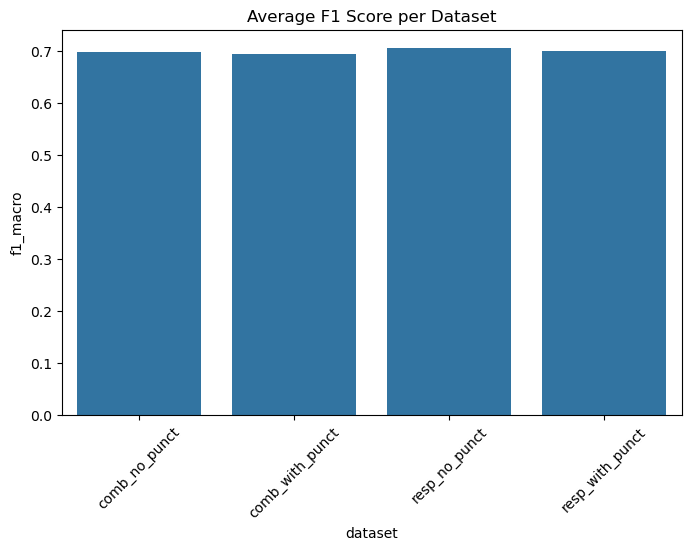

In [11]:
dataset_avg.reset_index(inplace=True)

plt.figure(figsize=(8,5))

sns.barplot(
    data=dataset_avg,
    x="dataset",
    y="f1_macro"
)

plt.title("Average F1 Score per Dataset")
plt.xticks(rotation=45)
plt.show()

In [12]:
pivot = results_df.pivot(index="model", columns="dataset", values="f1_macro")

pivot

dataset,comb_no_punct,comb_with_punct,resp_no_punct,resp_with_punct
model,,,,
Baseline,0.348419,0.348419,0.348419,0.348419
Logistic Regression,0.790512,0.788395,0.790883,0.788157
MLP,0.758152,0.745785,0.753267,0.750499
Naive Bayes,0.739630,0.735400,0.775447,0.768085
Random Forest,0.757325,0.754275,0.770603,0.758590
SVM,0.790149,0.786473,0.789371,0.783656


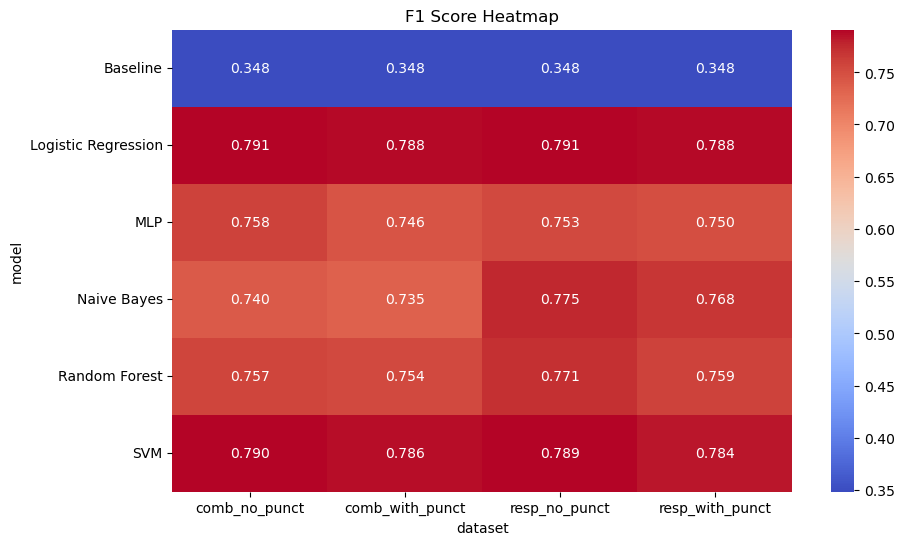

In [13]:
plt.figure(figsize=(10,6))

sns.heatmap(pivot, annot=True, fmt=".3f", cmap="coolwarm")

plt.title("F1 Score Heatmap")
plt.show()

In [14]:
best_model = model_avg.sort_values(by="f1_macro", ascending=False).iloc[0]

print("Best overall model:")
print(best_model)

Best overall model:
model        Logistic Regression
accuracy                0.790394
precision               0.789392
recall                  0.789662
f1_macro                0.789487
Name: 1, dtype: object


In [15]:
best_dataset = dataset_avg.sort_values(by="f1_macro", ascending=False).iloc[0]

print("Best dataset representation:")
print(best_dataset)

Best dataset representation:
dataset      resp_no_punct
accuracy          0.736371
precision         0.691328
recall            0.730446
f1_macro          0.704665
Name: 2, dtype: object
